In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [9]:
df1 = pd.read_csv("FAOSTAT_data_1-10-2022.csv")
df2 = pd.read_csv("FAOSTAT_data_en_11-1-2024.csv")
countries = pd.read_csv("FAOSTAT_data_11-24-2020.csv")

In [10]:
df1.head()

df1.shape

df1.info()

df1.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 229925 entries, 0 to 229924
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Domain Code       229925 non-null  object 
 1   Domain            229925 non-null  object 
 2   Area Code (FAO)   229925 non-null  int64  
 3   Area              229925 non-null  object 
 4   Element Code      229925 non-null  int64  
 5   Element           229925 non-null  object 
 6   Months Code       229925 non-null  int64  
 7   Months            229925 non-null  object 
 8   Year Code         229925 non-null  int64  
 9   Year              229925 non-null  int64  
 10  Unit              229925 non-null  object 
 11  Value             222012 non-null  float64
 12  Flag              229925 non-null  object 
 13  Flag Description  229925 non-null  object 
dtypes: float64(1), int64(5), object(8)
memory usage: 24.6+ MB


,Area Code (FAO),Element Code,Months Code,Year Code,Year,Value
count,229925.000000,229925.0,229925.000000,229925.000000,229925.000000,222012.000000
mean,130.647689,7271.0,7009.882353,1991.306248,1991.306248,0.492626
std,76.809008,0.0,6.037955,17.333252,17.333252,1.036364
min,1.000000,7271.0,7001.000000,1961.000000,1961.000000,-9.303000
25%,64.000000,7271.0,7005.000000,1976.000000,1976.000000,-0.071000
50%,131.000000,7271.0,7009.000000,1992.000000,1992.000000,0.414000
75%,194.000000,7271.0,7016.000000,2006.000000,2006.000000,0.999000
max,351.000000,7271.0,7020.000000,2020.000000,2020.000000,11.759000


In [11]:
import pandas as pd

df = pd.DataFrame({
    'Area': ['A1', 'A2', 'A3'],
    'Months': ['Jan', 'Feb', 'Mar'],
    'Year': [2021, 2022, 2023],
    'Value': [100, 200, 300],
    'ExtraColumn': [1, 2, 3]
})

df_clean = df[['Area', 'Months', 'Year', 'Value']]

In [12]:
df_clean.columns = ['Country','Month','Year','TemperatureChange']

In [15]:
df_clean['Year'] = df_clean['Year'].astype(int)
df_clean['TemperatureChange'] = pd.to_numeric(df_clean['TemperatureChange'], errors='coerce')

/var/folders/t0/_3l_nts555s4qpydh2dz6z140000gn/T/ipykernel_83743/3517069397.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['Year'] = df_clean['Year'].astype(int)
/var/folders/t0/_3l_nts555s4qpydh2dz6z140000gn/T/ipykernel_83743/3517069397.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_clean['TemperatureChange'] = pd.to_numeric(df_clean['TemperatureChange'], errors='coerce')


In [16]:
df_clean.isnull().sum()

Country              0
Month                0
Year                 0
TemperatureChange    0
dtype: int64

In [17]:
df_clean = df_clean.dropna()

In [18]:
df_clean.duplicated().sum()

np.int64(0)

In [19]:
df_clean = df_clean.drop_duplicates()

In [20]:
df_clean.describe()

,Year,TemperatureChange
count,3.0,3.0
mean,2022.0,200.0
std,1.0,100.0
min,2021.0,100.0
25%,2021.5,150.0
50%,2022.0,200.0
75%,2022.5,250.0
max,2023.0,300.0


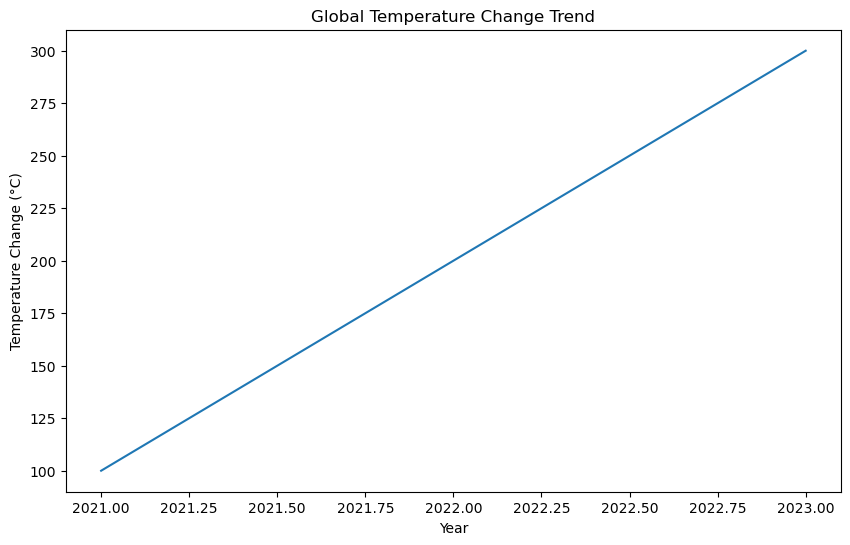

In [21]:
yearly_temp = df_clean.groupby("Year")["TemperatureChange"].mean()

plt.figure(figsize=(10,6))
plt.plot(yearly_temp)
plt.title("Global Temperature Change Trend")
plt.xlabel("Year")
plt.ylabel("Temperature Change (°C)")
plt.show()

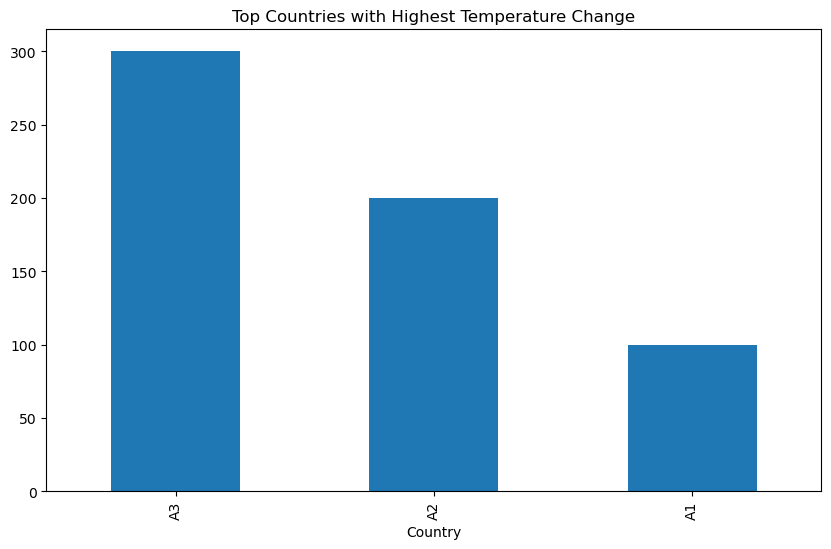

In [22]:
country_temp = df_clean.groupby("Country")["TemperatureChange"].mean()

top_countries = country_temp.sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
top_countries.plot(kind="bar")
plt.title("Top Countries with Highest Temperature Change")
plt.show()

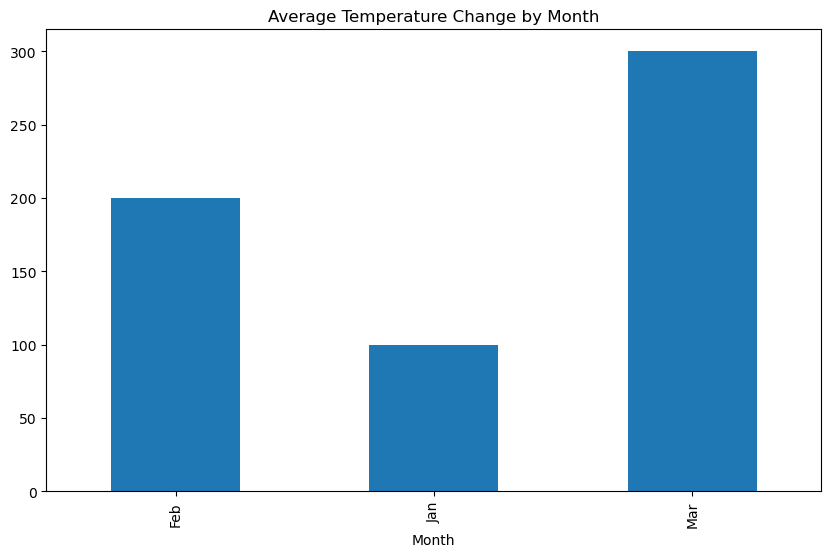

In [23]:
monthly_temp = df_clean.groupby("Month")["TemperatureChange"].mean()

plt.figure(figsize=(10,6))
monthly_temp.plot(kind="bar")
plt.title("Average Temperature Change by Month")
plt.show()

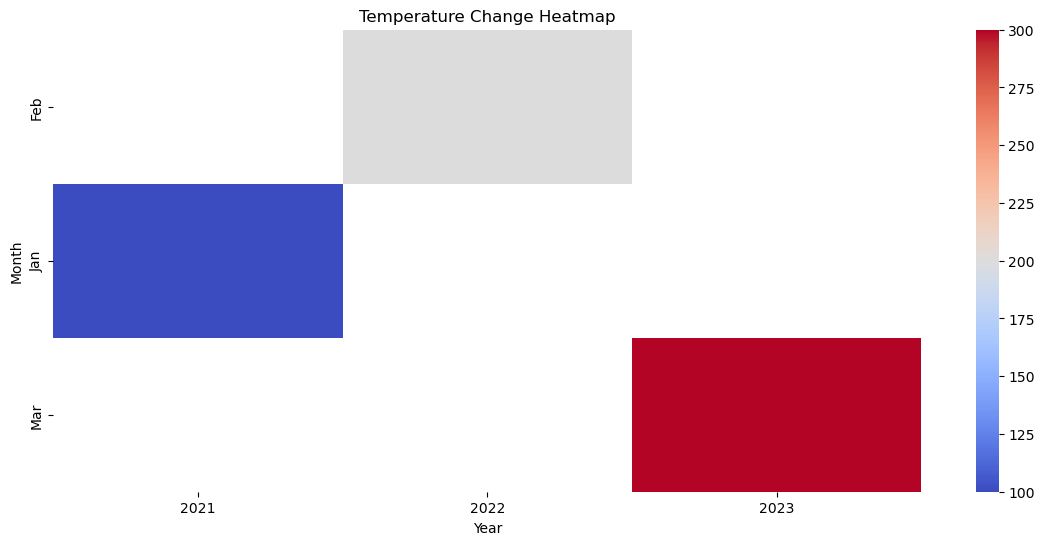

In [24]:
pivot_table = df_clean.pivot_table(
    values='TemperatureChange',
    index='Month',
    columns='Year',
    aggfunc='mean'
)

plt.figure(figsize=(14,6))
sns.heatmap(pivot_table, cmap='coolwarm')
plt.title("Temperature Change Heatmap")
plt.show()

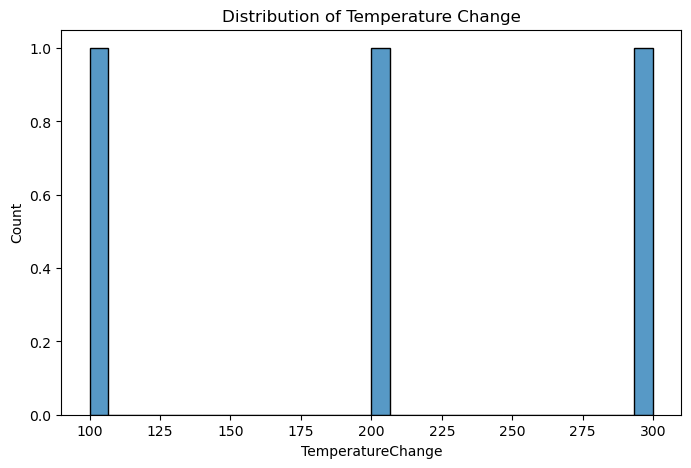

In [25]:
plt.figure(figsize=(8,5))
sns.histplot(df_clean['TemperatureChange'], bins=30)
plt.title("Distribution of Temperature Change")
plt.show()

In [26]:
#ödev2

In [27]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [28]:
df1 = pd.read_csv("FAOSTAT_data_1-10-2022.csv")
df2 = pd.read_csv("FAOSTAT_data_en_11-1-2024.csv")
countries = pd.read_csv("FAOSTAT_data_11-24-2020.csv")

In [29]:
print("df1 shape:", df1.shape)
print("df2 shape:", df2.shape)
print("countries shape:", countries.shape)

print("\ndf2 columns:")
print(df2.columns)

df2.head()

df1 shape: (229925, 14)
df2 shape: (241893, 14)
countries shape: (321, 7)

df2 columns:
Index(['Domain Code', 'Domain', 'Area Code (M49)', 'Area', 'Element Code',
       'Element', 'Months Code', 'Months', 'Year Code', 'Year', 'Unit',
       'Value', 'Flag', 'Flag Description'],
      dtype='object')


,Domain Code,Domain,Area Code (M49),Area,Element Code,Element,Months Code,Months,Year Code,Year,Unit,Value,Flag,Flag Description
0,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1961,1961,°c,0.745,E,Estimated value
1,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1962,1962,°c,0.015,E,Estimated value
2,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1963,1963,°c,2.706,E,Estimated value
3,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1964,1964,°c,-5.250,E,Estimated value
4,ET,Temperature change on land,4,Afghanistan,7271,Temperature change,7001,January,1965,1965,°c,1.854,E,Estimated value


In [30]:
df = df2[['Area', 'Months', 'Year', 'Value']].copy()
df.columns = ['Country', 'Month', 'Year', 'TemperatureChange']

df.head()

,Country,Month,Year,TemperatureChange
0,Afghanistan,January,1961,0.745
1,Afghanistan,January,1962,0.015
2,Afghanistan,January,1963,2.706
3,Afghanistan,January,1964,-5.250
4,Afghanistan,January,1965,1.854


In [31]:
df['Year'] = pd.to_numeric(df['Year'], errors='coerce')
df['TemperatureChange'] = pd.to_numeric(df['TemperatureChange'], errors='coerce')

print("Missing values before cleaning:")
print(df.isnull().sum())

df = df.dropna()
df = df.drop_duplicates()

print("\nShape after cleaning:", df.shape)
print(df.head())

Missing values before cleaning:
Country                  0
Month                    0
Year                     0
TemperatureChange    10260
dtype: int64

Shape after cleaning: (231633, 4)
       Country    Month  Year  TemperatureChange
0  Afghanistan  January  1961              0.745
1  Afghanistan  January  1962              0.015
2  Afghanistan  January  1963              2.706
3  Afghanistan  January  1964             -5.250
4  Afghanistan  January  1965              1.854


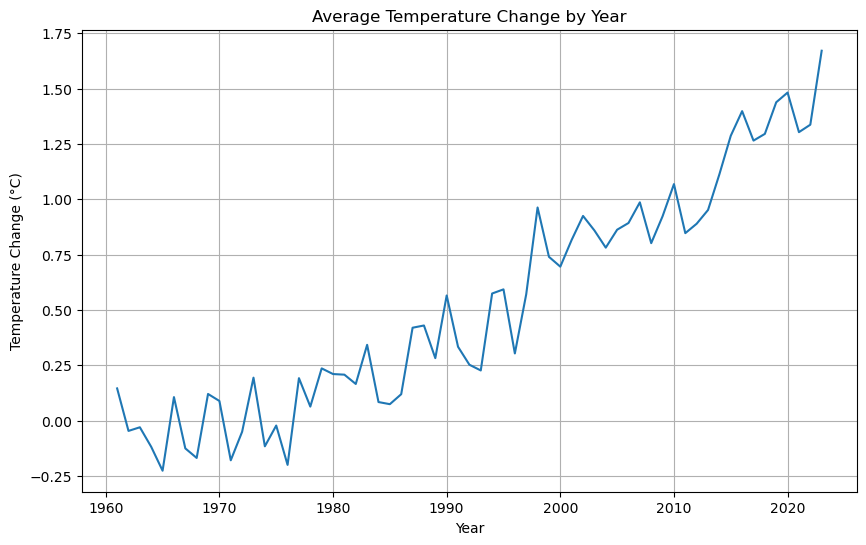

In [32]:
# Yearly average
yearly_temp = df.groupby("Year")["TemperatureChange"].mean()

plt.figure(figsize=(10,6))
plt.plot(yearly_temp.index, yearly_temp.values)
plt.title("Average Temperature Change by Year")
plt.xlabel("Year")
plt.ylabel("Temperature Change (°C)")
plt.grid(True)
plt.show()

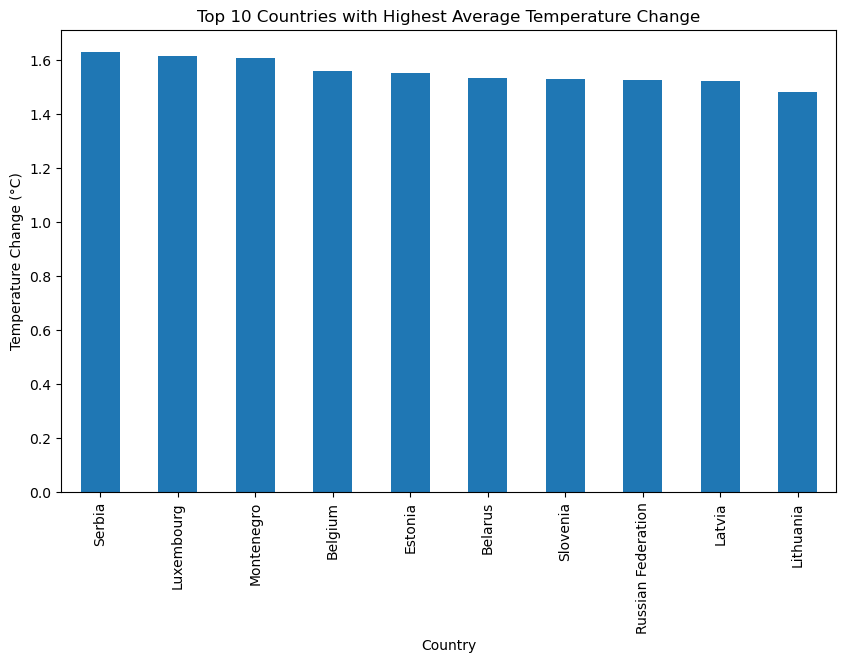

In [33]:
# Top countries
country_temp = df.groupby("Country")["TemperatureChange"].mean().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,6))
country_temp.plot(kind="bar")
plt.title("Top 10 Countries with Highest Average Temperature Change")
plt.xlabel("Country")
plt.ylabel("Temperature Change (°C)")
plt.show()

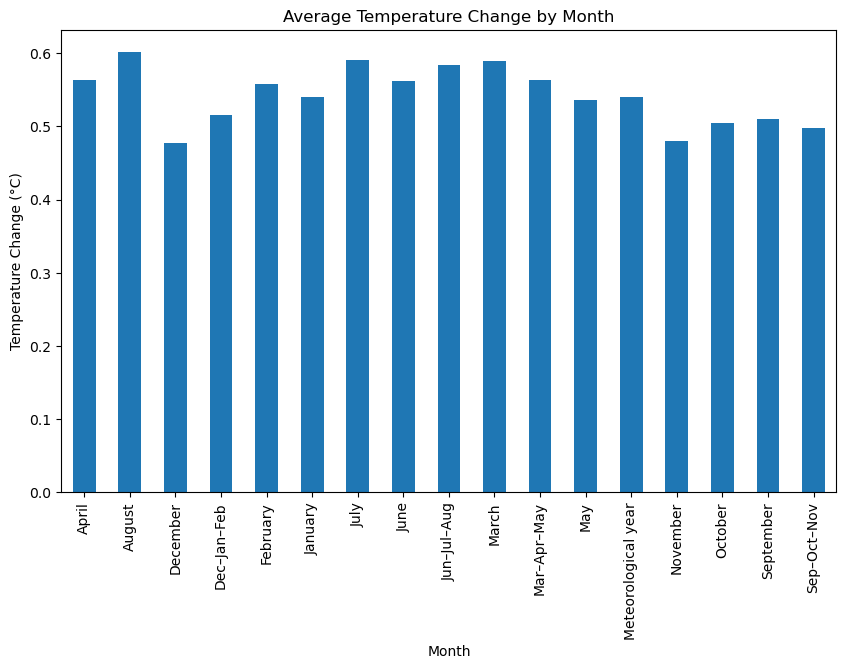

In [34]:
# Monthly averages
monthly_temp = df.groupby("Month")["TemperatureChange"].mean()

plt.figure(figsize=(10,6))
monthly_temp.plot(kind="bar")
plt.title("Average Temperature Change by Month")
plt.xlabel("Month")
plt.ylabel("Temperature Change (°C)")
plt.show()

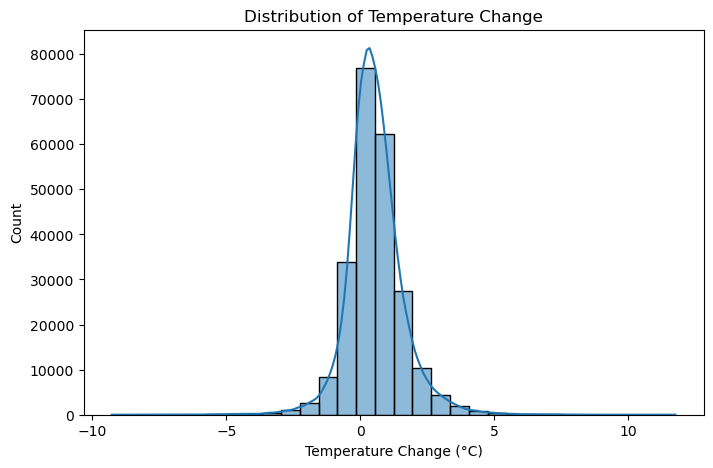

In [35]:
# Distribution
plt.figure(figsize=(8,5))
sns.histplot(df['TemperatureChange'], bins=30, kde=True)
plt.title("Distribution of Temperature Change")
plt.xlabel("Temperature Change (°C)")
plt.show()

In [36]:
X = df[['Country', 'Month', 'Year']]
y = df['TemperatureChange']

In [37]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)

Train size: (185306, 3)
Test size: (46327, 3)


In [38]:
categorical_features = ['Country', 'Month']
numeric_features = ['Year']

numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transformer, numeric_features),
    ('cat', categorical_transformer, categorical_features)
])

In [39]:
lr_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

lr_model.fit(X_train, y_train)

y_pred_lr = lr_model.predict(X_test)

In [40]:
rf_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        max_depth=15
    ))
])

rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

In [41]:
def evaluate_model(y_true, y_pred, model_name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    
    print(f"{model_name} Results")
    print("-" * 30)
    print("MAE :", round(mae, 4))
    print("MSE :", round(mse, 4))
    print("RMSE:", round(rmse, 4))
    print("R^2 :", round(r2, 4))
    print()
    
    return {
        'Model': model_name,
        'MAE': mae,
        'MSE': mse,
        'RMSE': rmse,
        'R2': r2
    }

lr_results = evaluate_model(y_test, y_pred_lr, "Linear Regression")
rf_results = evaluate_model(y_test, y_pred_rf, "Random Forest Regressor")

Linear Regression Results
------------------------------
MAE : 0.6208
MSE : 0.8615
RMSE: 0.9282
R^2 : 0.233

Random Forest Regressor Results
------------------------------
MAE : 0.6111
MSE : 0.8374
RMSE: 0.9151
R^2 : 0.2544



In [42]:
results_df = pd.DataFrame([lr_results, rf_results])
results_df

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,0.620760,0.861532,0.928187,0.232981
1,Random Forest Regressor,0.611133,0.837428,0.915111,0.254440


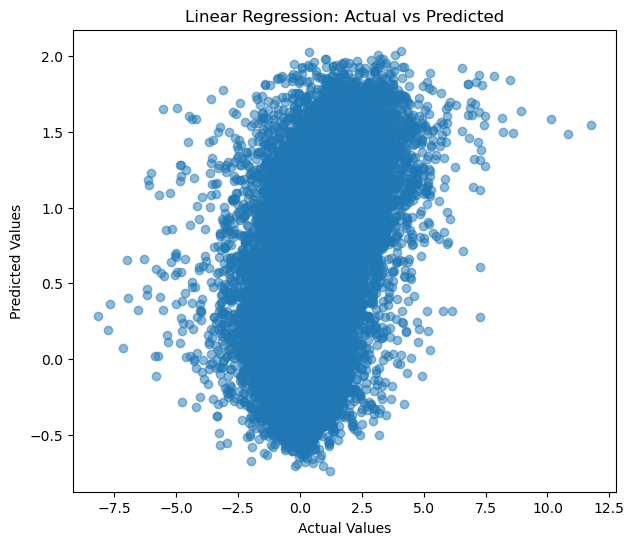

In [43]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_lr, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Linear Regression: Actual vs Predicted")
plt.show()

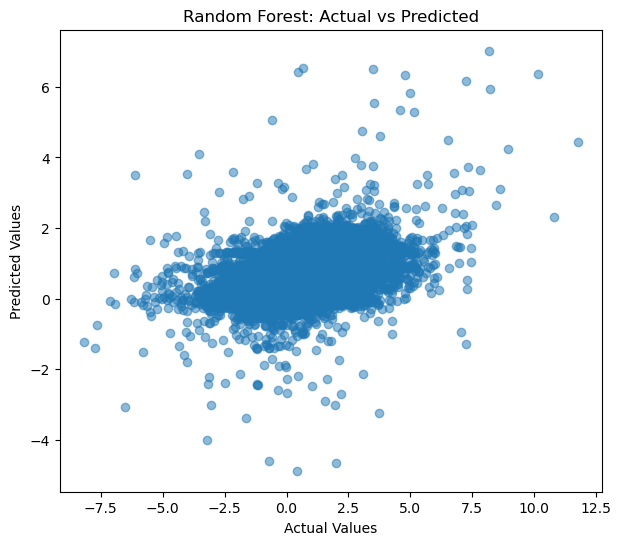

In [44]:
plt.figure(figsize=(7,6))
plt.scatter(y_test, y_pred_rf, alpha=0.5)
plt.xlabel("Actual Values")
plt.ylabel("Predicted Values")
plt.title("Random Forest: Actual vs Predicted")
plt.show()

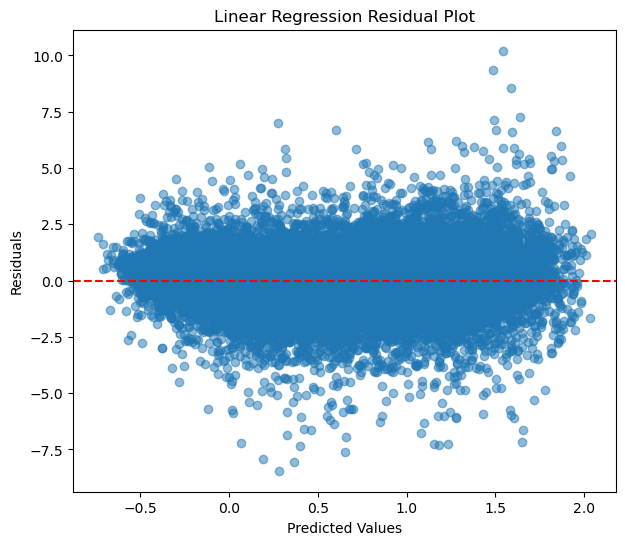

In [45]:
residuals_lr = y_test - y_pred_lr
residuals_rf = y_test - y_pred_rf

plt.figure(figsize=(7,6))
plt.scatter(y_pred_lr, residuals_lr, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Linear Regression Residual Plot")
plt.show()

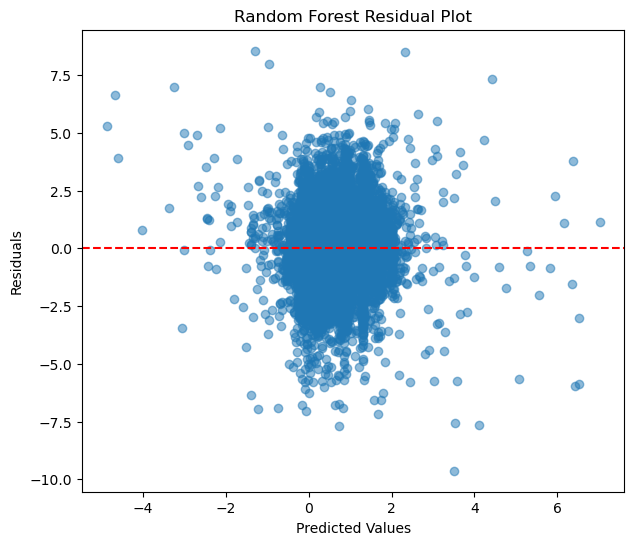

In [46]:
plt.figure(figsize=(7,6))
plt.scatter(y_pred_rf, residuals_rf, alpha=0.5)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Random Forest Residual Plot")
plt.show()

In [47]:
# Preprocessor içindeki one-hot encoded feature isimlerini alma
ohe = rf_model.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
encoded_cat_features = ohe.get_feature_names_out(categorical_features)

all_features = numeric_features + list(encoded_cat_features)

importances = rf_model.named_steps['model'].feature_importances_

feature_importance_df = pd.DataFrame({
    'Feature': all_features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

feature_importance_df.head(15)

,Feature,Importance
0,Year,0.715019
252,Month_February,0.024502
253,Month_January,0.021447
212,Country_Svalbard and Jan Mayen Islands,0.019690
250,Month_December,0.015582
257,Month_March,0.014470
251,Month_Dec–Jan–Feb,0.010167
261,Month_November,0.009603
80,Country_Finland,0.009334
248,Month_April,0.007895


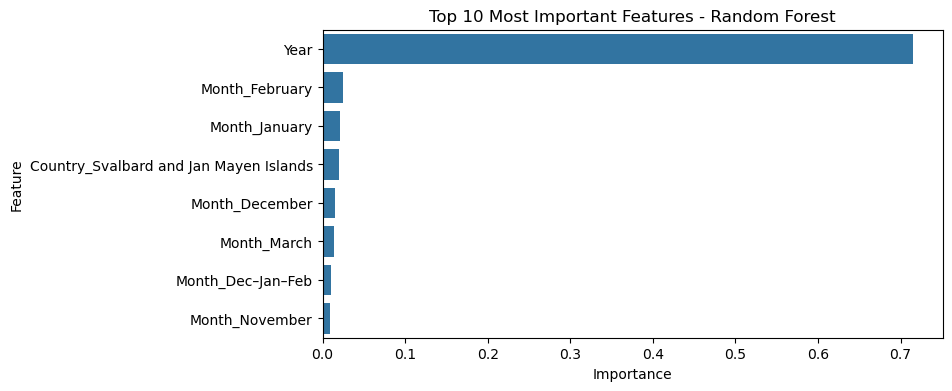

In [51]:
plt.figure(figsize=(8,4))
sns.barplot(data=feature_importance_df.head(8), x='Importance', y='Feature')
plt.title("Top 10 Most Important Features - Random Forest")
plt.show()